# 📊 Análisis de Eventos TechNova con Apache Spark

---

## 🎯 Objetivo del Análisis

Procesar los eventos generados por la aplicación de microservicios **TechNova** usando Apache Spark para obtener métricas analíticas de valor que ayuden a entender el comportamiento de usuarios y el rendimiento del sistema.

---

## 📋 Dataset: Events Log

**Fuente:** Logs de eventos de la aplicación TechNova  
**Registros:** ~687 eventos  
**Período:** Mayo 2026

### Columnas del Dataset:
* `timestamp` - Fecha y hora del evento
* `event_type` - Tipo de evento (product_viewed, user_registered, purchase, etc.)
* `category` - Categoría del producto
* `device` - Dispositivo usado (desktop, mobile)
* `latency_ms` - Latencia en milisegundos
* `status` - Estado de la operación (success, error)
* `user_id` - ID del usuario
* `product_id` - ID del producto
* `product_name` - Nombre del producto

---

## 🔍 Métricas de Interés

1. **Total de eventos por tipo** → Entender qué acciones realizan más los usuarios
2. **Productos más vistos** → Identificar productos populares
3. **Latencia promedio por tipo de evento** → Detectar operaciones lentas
4. **Tasa de éxito/error** → Monitorear calidad del servicio
5. **Eventos por dispositivo** → Optimizar experiencia móvil vs desktop
6. **Actividad por hora** → Identificar picos de tráfico

In [0]:
# ============================================================
# CONFIGURACION SEGURA DE STORAGE PARA EL LABORATORIO
# Siguiendo el patron del profesor Heberth Martinez
# ============================================================

# Nombre del catalogo para el laboratorio
CATALOG_NAME = "technova_analytics"

# Nombre del schema/base de datos dentro del catalogo
SCHEMA_NAME = "events"

# Nombre del volumen donde guardaremos archivos y Delta tables
VOLUME_NAME = "events_data"

# Crea el catalogo si no existe
spark.sql(f"CREATE CATALOG IF NOT EXISTS {CATALOG_NAME}")

# Crea el schema si no existe
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CATALOG_NAME}.{SCHEMA_NAME}")

# Crea el volumen si no existe
spark.sql(
    f"""
    CREATE VOLUME IF NOT EXISTS {CATALOG_NAME}.{SCHEMA_NAME}.{VOLUME_NAME}
    """
)

# Ruta base para Spark
BASE_PATH = f"/Volumes/{CATALOG_NAME}/{SCHEMA_NAME}/{VOLUME_NAME}"

# Rutas logicas de trabajo para Spark
LANDING_PATH = f"{BASE_PATH}/landing"
SILVER_PATH = f"{BASE_PATH}/silver_delta"
GOLD_PATH = f"{BASE_PATH}/gold_delta"

print("Storage configurado correctamente.")
print(f"Ruta Spark landing: {LANDING_PATH}")
print(f"Ruta Spark silver:  {SILVER_PATH}")
print(f"Ruta Spark gold:    {GOLD_PATH}")

Storage configurado correctamente.
Ruta Spark landing: /Volumes/technova_analytics/events/events_data/landing
Ruta Spark silver:  /Volumes/technova_analytics/events/events_data/silver_delta
Ruta Spark gold:    /Volumes/technova_analytics/events/events_data/gold_delta


In [0]:
# Funciones comunes de Spark SQL
from pyspark.sql import functions as F

# Window functions para analisis por grupos ordenados
from pyspark.sql.window import Window

# Tipos de datos explicitos
from pyspark.sql.types import DoubleType, IntegerType, TimestampType

# Librerias para visualizacion
import matplotlib.pyplot as plt
import time

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [0]:
# ============================================================
# CARGA DE DATOS - EVENTS LOG
# ============================================================

print("Cargando eventos desde workspace...")
start_time = time.time()

# Ruta del archivo CSV en workspace
events_csv_path = "/Workspace/Users/sebastian.celorio@uao.edu.co/events.csv"

# Leer CSV con Spark
events_raw_df = (
    spark.read
    .format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .load(events_csv_path)
)

load_time = time.time() - start_time

# Contar registros
total_events = events_raw_df.count()

print(f"Eventos cargados: {total_events:,}")
print(f"Tiempo de carga: {load_time:.2f} segundos")
print(f"\nSchema del dataset:")
events_raw_df.printSchema()

print(f"\nPrimeros registros:")
display(events_raw_df.limit(10))

Cargando eventos desde workspace...
Eventos cargados: 686
Tiempo de carga: 0.00 segundos

Schema del dataset:
root
 |-- timestamp: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- category: string (nullable = true)
 |-- device: string (nullable = true)
 |-- email: string (nullable = true)
 |-- error_type: string (nullable = true)
 |-- items_count: integer (nullable = true)
 |-- latency_ms: integer (nullable = true)
 |-- price: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- session_id: string (nullable = true)
 |-- status: string (nullable = true)
 |-- user_id: integer (nullable = true)


Primeros registros:


timestamp,event_type,category,device,email,error_type,items_count,latency_ms,price,product_id,product_name,quantity,session_id,status,user_id
2026-05-22T23:28:50.505Z,product_viewed,Componentes,desktop,null,null,null,null,1600,1,Tarjeta Gráfica RTX 4090,null,sess_5sxa40vn9k,null,1
2026-05-23T02:50:41.505Z,product_viewed,Componentes,mobile,null,null,null,null,1600,1,Tarjeta Gráfica RTX 4090,null,sess_4i8himgaz4x,null,1
2026-05-22T22:35:52.558Z,user_registered,null,mobile,navegante_4305@technova.com,null,null,53,null,null,null,null,sess_10bxb3esl1tl,success,3747
2026-05-23T20:49:35.560Z,user_registered,null,desktop,comprador_34909@technova.com,null,null,55,null,null,null,null,sess_cyzdz46563b,success,3745
2026-05-23T03:18:55.562Z,user_registered,null,desktop,comprador_85710@technova.com,null,null,57,null,null,null,null,sess_an0ju48vx5,success,3748
2026-05-23T17:26:47.564Z,user_registered,null,desktop,comprador_67322@technova.com,null,null,59,null,null,null,null,sess_8vlb1mqnxzb,success,3751
2026-05-23T14:27:05.566Z,user_registered,null,desktop,comprador_98638@technova.com,null,null,61,null,null,null,null,sess_95npx4uc7bp,success,3744
2026-05-23T18:59:46.568Z,user_registered,null,desktop,comprador_94423@technova.com,null,null,63,null,null,null,null,sess_i41ouyyvn5,success,3749
2026-05-23T02:23:36.569Z,user_registered,null,desktop,comprador_93160@technova.com,null,null,64,null,null,null,null,sess_jngwkvlnbqe,success,3746
2026-05-23T22:12:45.575Z,user_registered,null,desktop,navegante_94661@technova.com,null,null,70,null,null,null,null,sess_sxt5xgg2lmr,success,3750


In [0]:
# ============================================================
# CAPA SILVER: LIMPIEZA Y TRANSFORMACION
# ============================================================

print("Construyendo capa Silver...")
start_time = time.time()

events_silver_df = (
    events_raw_df
    
    # Convertir timestamp a tipo correcto
    .withColumn("event_timestamp", F.to_timestamp("timestamp"))
    
    # Extraer componentes de fecha/hora
    .withColumn("event_date", F.to_date("event_timestamp"))
    .withColumn("event_hour", F.hour("event_timestamp"))
    .withColumn("event_day_of_week", F.dayofweek("event_timestamp"))
    
    # Limpiar latency_ms
    .withColumn("latency_ms", F.col("latency_ms").cast(IntegerType()))
    
    # Limpiar price
    .withColumn("price", F.col("price").cast(DoubleType()))
    
    # Normalizar device
    .withColumn("device", F.lower(F.trim(F.col("device"))))
    
    # Normalizar event_type
    .withColumn("event_type", F.lower(F.trim(F.col("event_type"))))
    
    # Filtrar registros validos
    .filter(F.col("event_timestamp").isNotNull())
    .filter(F.col("event_type").isNotNull())
)

silver_time = time.time() - start_time
silver_count = events_silver_df.count()

print(f"Capa Silver creada")
print(f"Registros limpios: {silver_count:,}")
print(f"Tiempo de procesamiento: {silver_time:.2f} segundos")

print(f"\nMuestra de datos limpios:")
display(events_silver_df.limit(5))

Construyendo capa Silver...
Capa Silver creada
Registros limpios: 686
Tiempo de procesamiento: 0.00 segundos

Muestra de datos limpios:


timestamp,event_type,category,device,email,error_type,items_count,latency_ms,price,product_id,product_name,quantity,session_id,status,user_id,event_timestamp,event_date,event_hour,event_day_of_week
2026-05-22T23:28:50.505Z,product_viewed,Componentes,desktop,null,null,null,null,1600.0,1,Tarjeta Gráfica RTX 4090,null,sess_5sxa40vn9k,null,1,2026-05-22T23:28:50.505Z,2026-05-22,23,6
2026-05-23T02:50:41.505Z,product_viewed,Componentes,mobile,null,null,null,null,1600.0,1,Tarjeta Gráfica RTX 4090,null,sess_4i8himgaz4x,null,1,2026-05-23T02:50:41.505Z,2026-05-23,2,7
2026-05-22T22:35:52.558Z,user_registered,null,mobile,navegante_4305@technova.com,null,null,53,null,null,null,null,sess_10bxb3esl1tl,success,3747,2026-05-22T22:35:52.558Z,2026-05-22,22,6
2026-05-23T20:49:35.560Z,user_registered,null,desktop,comprador_34909@technova.com,null,null,55,null,null,null,null,sess_cyzdz46563b,success,3745,2026-05-23T20:49:35.560Z,2026-05-23,20,7
2026-05-23T03:18:55.562Z,user_registered,null,desktop,comprador_85710@technova.com,null,null,57,null,null,null,null,sess_an0ju48vx5,success,3748,2026-05-23T03:18:55.562Z,2026-05-23,3,7


In [0]:
# ============================================================
# PERSISTIR CAPA SILVER EN FORMATO DELTA
# ============================================================

print("Guardando capa Silver en Delta Lake...")

(
    events_silver_df
    .write
    .format("delta")
    .mode("overwrite")
    .partitionBy("event_date")
    .save(SILVER_PATH)
)

print(f"Silver Delta guardado en: {SILVER_PATH}")

# Registrar como vista temporal
events_silver_df.createOrReplaceTempView("events_silver")

Guardando capa Silver en Delta Lake...
Silver Delta guardado en: /Volumes/technova_analytics/events/events_data/silver_delta


---

# 📊 Métricas Analíticas (Gold Layer)

---

Ahora generamos las **métricas de valor** para el negocio usando Spark.

METRICA 1: Eventos por Tipo

Distribucion de eventos:


event_type,total_events,avg_latency_ms
product_viewed,204,null
order_attempted,132,null
user_registered,99,24.45
order_failed,77,20.61
user_logged_in,72,13.35
order_completed,55,40.78
catalog_browsed,47,8.15


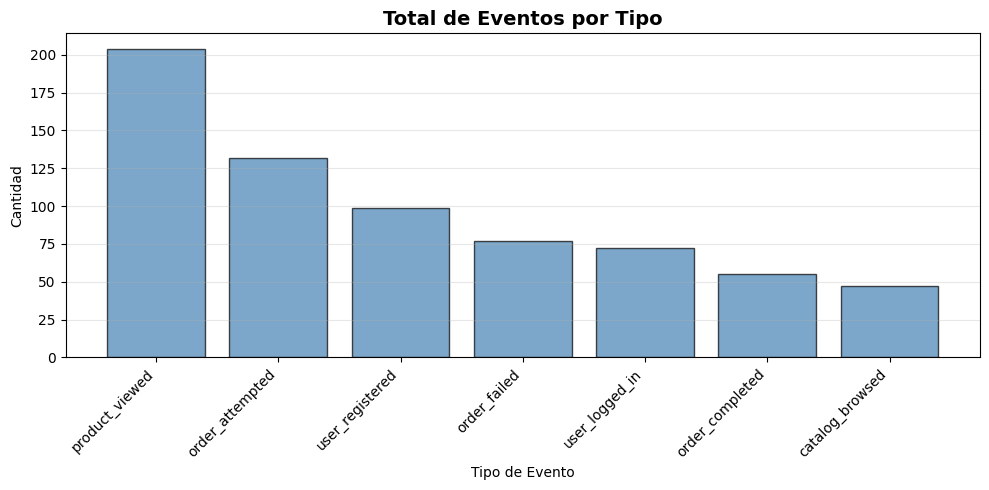


VALOR DE LA METRICA:
Esta metrica permite identificar que acciones realizan mas los usuarios.
Ayuda a priorizar optimizaciones en los endpoints mas usados.


In [0]:
# ============================================================
# METRICA 1: TOTAL DE EVENTOS POR TIPO
# ============================================================

print("METRICA 1: Eventos por Tipo")
print("=" * 50)

events_by_type_df = (
    events_silver_df
    .groupBy("event_type")
    .agg(
        F.count("*").alias("total_events"),
        F.round(F.avg("latency_ms"), 2).alias("avg_latency_ms")
    )
    .orderBy(F.desc("total_events"))
)

print("\nDistribucion de eventos:")
display(events_by_type_df)

# Visualizacion
events_by_type_pd = events_by_type_df.toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(events_by_type_pd['event_type'], events_by_type_pd['total_events'], color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Total de Eventos por Tipo', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Evento')
ax.set_ylabel('Cantidad')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nVALOR DE LA METRICA:")
print("Esta metrica permite identificar que acciones realizan mas los usuarios.")
print("Ayuda a priorizar optimizaciones en los endpoints mas usados.")

METRICA 2: Top 10 Productos Mas Vistos

Top 10 productos:


product_name,category,views,avg_price
Tarjeta Gráfica RTX 4090,Componentes,73,1600.0
Placa Base ASUS ROG,Componentes,17,350.0
Procesador Intel Core i9,Componentes,16,600.0
"""Monitor Gaming 27"""" 144Hz""",Monitores,16,300.0
Unidad SSD 1TB NVMe M.2,Almacenamiento,16,110.0
Mouse Gamer Inalámbrico,Periféricos,16,70.0
Teclado Mecánico RGB,Periféricos,14,90.0
Memoria RAM 32GB DDR5,Memorias,13,150.0
Auriculares Gaming 7.1,Audio,13,85.0
Fuente de Poder 850W,Componentes,10,120.0


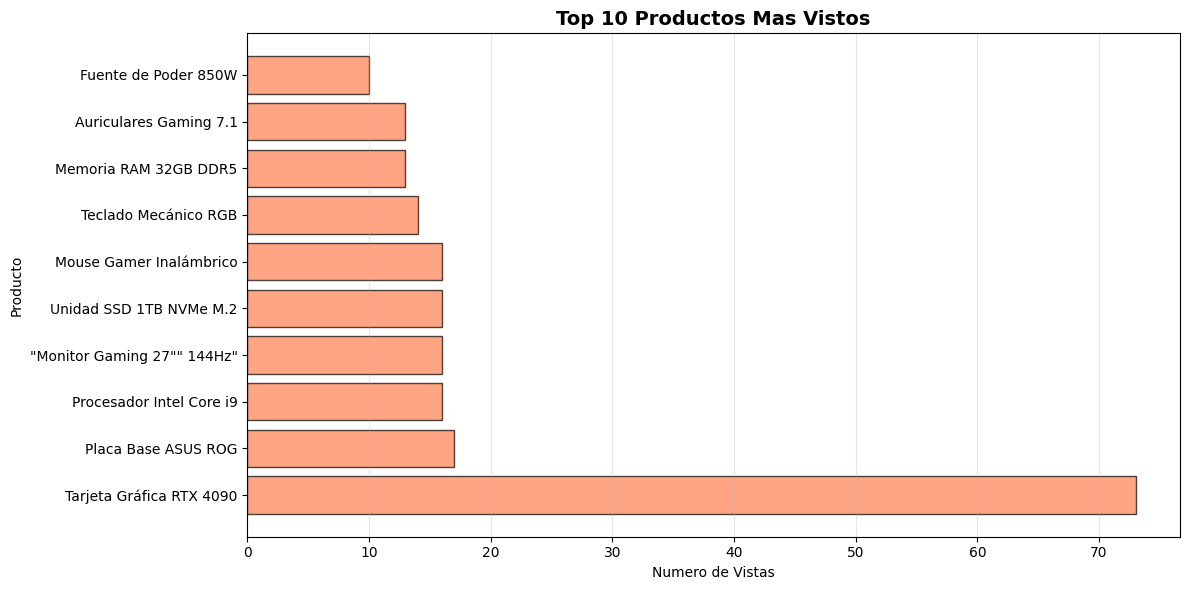


VALOR DE LA METRICA:
Identifica los productos mas populares para:
  - Optimizar inventario
  - Mejorar recomendaciones
  - Planear campanas de marketing


In [0]:
# ============================================================
# METRICA 2: PRODUCTOS MAS VISTOS
# ============================================================

print("METRICA 2: Top 10 Productos Mas Vistos")
print("=" * 50)

top_products_df = (
    events_silver_df
    .filter(F.col("event_type") == "product_viewed")
    .filter(F.col("product_name").isNotNull())
    .groupBy("product_name", "category")
    .agg(
        F.count("*").alias("views"),
        F.avg("price").alias("avg_price")
    )
    .orderBy(F.desc("views"))
    .limit(10)
)

print("\nTop 10 productos:")
display(top_products_df)

# Visualizacion
top_products_pd = top_products_df.toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_products_pd['product_name'], top_products_pd['views'], color='coral', edgecolor='black', alpha=0.7)
ax.set_title('Top 10 Productos Mas Vistos', fontsize=14, fontweight='bold')
ax.set_xlabel('Numero de Vistas')
ax.set_ylabel('Producto')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVALOR DE LA METRICA:")
print("Identifica los productos mas populares para:")
print("  - Optimizar inventario")
print("  - Mejorar recomendaciones")
print("  - Planear campanas de marketing")

METRICA 3: Latencia Promedio por Tipo de Evento

Latencias por tipo:


event_type,avg_latency_ms,min_latency_ms,max_latency_ms,sample_size
order_completed,40.78,12,95,55
user_registered,24.45,6,72,99
order_failed,20.61,9,57,77
user_logged_in,13.35,5,48,72
catalog_browsed,8.15,4,34,47


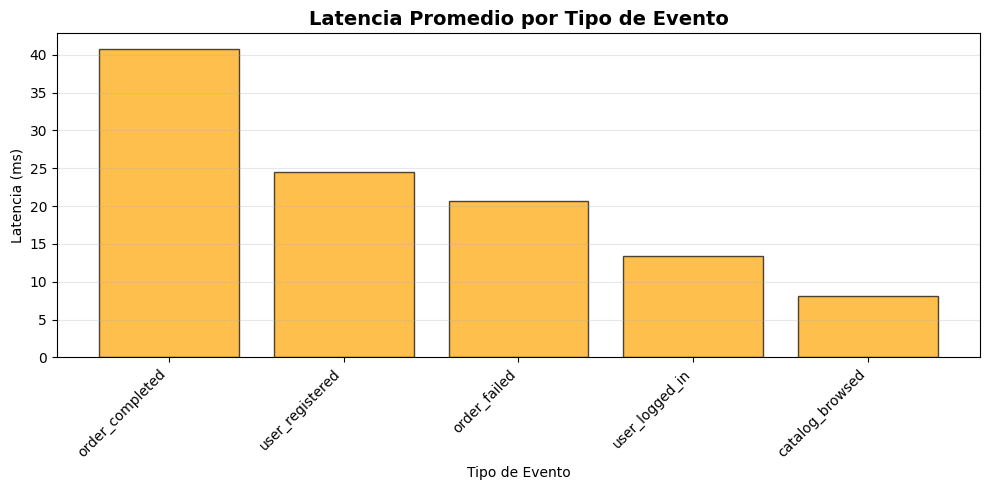


VALOR DE LA METRICA:
Detecta operaciones lentas que afectan la experiencia del usuario.
Permite priorizar optimizaciones de rendimiento.


In [0]:
# ============================================================
# METRICA 3: LATENCIA PROMEDIO POR TIPO DE EVENTO
# ============================================================

print("METRICA 3: Latencia Promedio por Tipo de Evento")
print("=" * 50)

latency_by_type_df = (
    events_silver_df
    .filter(F.col("latency_ms").isNotNull())
    .groupBy("event_type")
    .agg(
        F.round(F.avg("latency_ms"), 2).alias("avg_latency_ms"),
        F.min("latency_ms").alias("min_latency_ms"),
        F.max("latency_ms").alias("max_latency_ms"),
        F.count("*").alias("sample_size")
    )
    .orderBy(F.desc("avg_latency_ms"))
)

print("\nLatencias por tipo:")
display(latency_by_type_df)

# Visualizacion
latency_pd = latency_by_type_df.toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(latency_pd['event_type'], latency_pd['avg_latency_ms'], color='orange', edgecolor='black', alpha=0.7)
ax.set_title('Latencia Promedio por Tipo de Evento', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Evento')
ax.set_ylabel('Latencia (ms)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nVALOR DE LA METRICA:")
print("Detecta operaciones lentas que afectan la experiencia del usuario.")
print("Permite priorizar optimizaciones de rendimiento.")

In [0]:
# ============================================================
# METRICA 4: TASA DE EXITO/ERROR POR TIPO DE EVENTO
# ============================================================

print("METRICA 4: Tasa de Exito por Tipo de Evento")
print("=" * 50)

success_rate_df = (
    events_silver_df
    .filter(F.col("status").isNotNull())
    .groupBy("event_type")
    .agg(
        F.count("*").alias("total"),
        F.sum(F.when(F.col("status") == "success", 1).otherwise(0)).alias("success"),
        F.sum(F.when(F.col("status") != "success", 1).otherwise(0)).alias("errors")
    )
    .withColumn("success_rate_%", F.round((F.col("success") / F.col("total")) * 100, 2))
    .orderBy(F.desc("total"))
)

print("\nTasas de exito:")
display(success_rate_df)

print("\nVALOR DE LA METRICA:")
print("Monitorea la calidad del servicio.")
print("Alerta sobre problemas en operaciones criticas (registros, compras).")

METRICA 4: Tasa de Exito por Tipo de Evento

Tasas de exito:


event_type,total,success,errors,success_rate_%
user_registered,99,96,3,96.97
order_failed,77,0,77,0.0
user_logged_in,72,72,0,100.0
order_completed,55,55,0,100.0
catalog_browsed,47,47,0,100.0



VALOR DE LA METRICA:
Monitorea la calidad del servicio.
Alerta sobre problemas en operaciones criticas (registros, compras).


METRICA 5: Eventos por Dispositivo

Distribucion por dispositivo:


device,total_events,avg_latency_ms
desktop,469,22.48
mobile,217,19.83


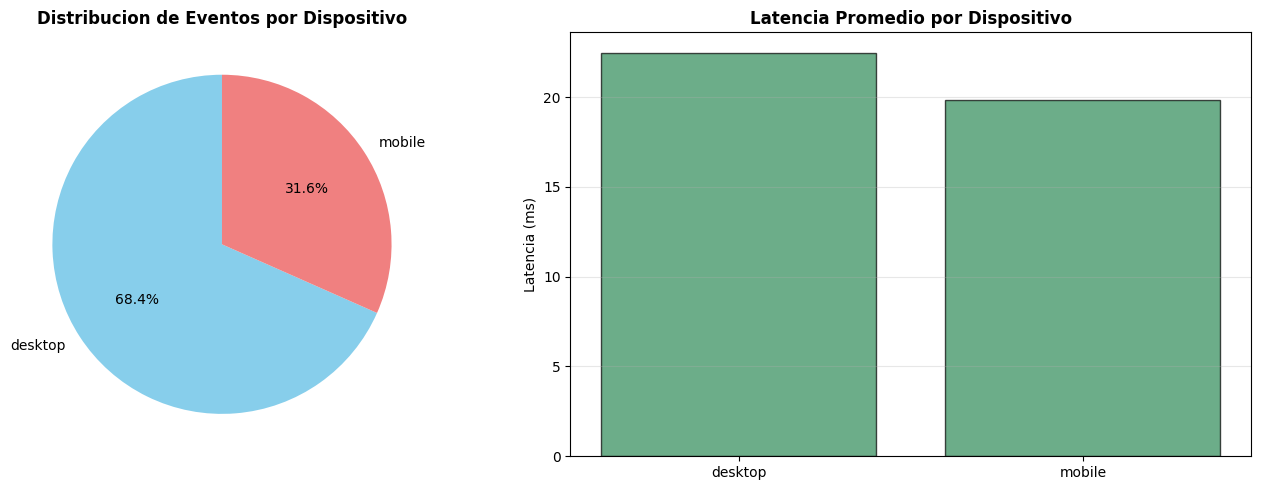


VALOR DE LA METRICA:
Identifica si la experiencia movil es diferente a desktop.
Ayuda a optimizar el frontend para cada tipo de dispositivo.


In [0]:
# ============================================================
# METRICA 5: DISTRIBUCION POR DISPOSITIVO
# ============================================================

print("METRICA 5: Eventos por Dispositivo")
print("=" * 50)

events_by_device_df = (
    events_silver_df
    .filter(F.col("device").isNotNull())
    .groupBy("device")
    .agg(
        F.count("*").alias("total_events"),
        F.round(F.avg("latency_ms"), 2).alias("avg_latency_ms")
    )
    .orderBy(F.desc("total_events"))
)

print("\nDistribucion por dispositivo:")
display(events_by_device_df)

# Visualizacion
device_pd = events_by_device_df.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafica 1: Distribucion de eventos
axes[0].pie(device_pd['total_events'], labels=device_pd['device'], autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=90)
axes[0].set_title('Distribucion de Eventos por Dispositivo', fontsize=12, fontweight='bold')

# Grafica 2: Latencia por dispositivo
axes[1].bar(device_pd['device'], device_pd['avg_latency_ms'], color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Latencia Promedio por Dispositivo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Latencia (ms)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVALOR DE LA METRICA:")
print("Identifica si la experiencia movil es diferente a desktop.")
print("Ayuda a optimizar el frontend para cada tipo de dispositivo.")

METRICA 6: Actividad por Hora del Dia

Eventos por hora:


event_hour,total_events
0,67
1,60
2,46
3,50
4,14
5,19
6,3
7,3
8,2
9,8


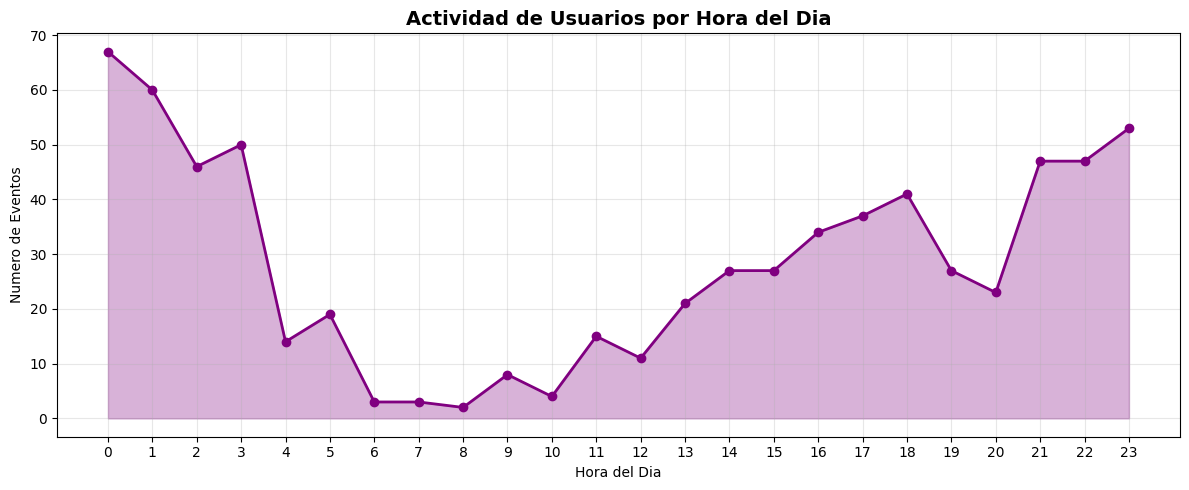


VALOR DE LA METRICA:
Identifica picos de trafico para:
  - Escalar recursos en horas de alta demanda
  - Programar mantenimientos en horas valle
  - Optimizar campanas de marketing


In [0]:
# ============================================================
# METRICA 6: ACTIVIDAD POR HORA DEL DIA
# ============================================================

print("METRICA 6: Actividad por Hora del Dia")
print("=" * 50)

events_by_hour_df = (
    events_silver_df
    .groupBy("event_hour")
    .agg(
        F.count("*").alias("total_events")
    )
    .orderBy("event_hour")
)

print("\nEventos por hora:")
display(events_by_hour_df)

# Visualizacion
hourly_pd = events_by_hour_df.toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_pd['event_hour'], hourly_pd['total_events'], marker='o', linewidth=2, color='purple')
ax.fill_between(hourly_pd['event_hour'], hourly_pd['total_events'], alpha=0.3, color='purple')
ax.set_title('Actividad de Usuarios por Hora del Dia', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del Dia')
ax.set_ylabel('Numero de Eventos')
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

print("\nVALOR DE LA METRICA:")
print("Identifica picos de trafico para:")
print("  - Escalar recursos en horas de alta demoanda")
print("  - Programar mantenimientos en horas valle")
print("  - Optimizar campanas de marketing")

---

# 📝 Resumen del Análisis con Spark

---

## ✅ Métricas Generadas

| # | Métrica | Valor para el Proyecto |
|---|---------|------------------------|
| 1 | **Eventos por Tipo** | Identifica las acciones más frecuentes de los usuarios |
| 2 | **Productos Más Vistos** | Optimiza inventario y estrategia de marketing |
| 3 | **Latencia Promedio** | Detecta operaciones lentas que afectan UX |
| 4 | **Tasa de Éxito** | Monitorea calidad del servicio y estabilidad |
| 5 | **Eventos por Dispositivo** | Optimiza experiencia móvil vs desktop |
| 6 | **Actividad por Hora** | Optimiza escalado de recursos y mantenimientos |

---

## 🎯 Por qué estas métricas aportan valor:

### 📊 **Para el Negocio:**
* Identifica productos populares para gestión de inventario
* Detecta patrones de comportamiento de usuarios
* Optimiza estrategias de marketing basadas en horarios

### ⚙️ **Para Operaciones:**
* Detecta cuellos de botella de rendimiento
* Monitorea estabilidad del sistema
* Optimiza asignación de recursos según demanda

### 👥 **Para Experiencia de Usuario:**
* Identifica diferencias entre móvil y desktop
* Mejora tiempos de respuesta
* Reduce errores en operaciones críticas

---

## 🚀 Ventajas de usar Spark:

1. **Escalabilidad** - Puede procesar millones de eventos fácilmente
2. **Procesamiento distribuido** - Análisis rápido de grandes volúmenes
3. **Integración con Delta Lake** - Almacenamiento optimizado y versionado
4. **Unity Catalog** - Gobernanza y seguridad de datos
5. **Análisis en tiempo real** - Posibilidad de streaming analytics

---

## 📦 Entregables:

✅ Notebook completo con código Spark  
✅ 6 métricas analíticas de valor  
✅ Visualizaciones de cada métrica  
✅ Explicación del valor de negocio  
✅ Datos almacenados en Delta Lake  
✅ Configuración segura con Unity Catalog